# 02 · Internal outcome evidence: JDS effect sizes & SDS context
**Team DSA · NEXUS DELTA · Build for Bharat 2.0 Round 2**  
Run top-to-bottom (Colab: Runtime → Run all). Notebooks 01→06 share files in `out/`.

In [1]:
import os, json, re, warnings, time
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
SEED = 42
np.random.seed(SEED)
# ---- Colab: upload the 4 organiser files to /content (left sidebar) or mount Drive and change DATA_DIR ----
DATA_DIR = "."
os.makedirs("figs", exist_ok=True); os.makedirs("out", exist_ok=True)
RES = "out/results.json"
def save_res(key, val):
    r = json.load(open(RES)) if os.path.exists(RES) else {}
    r[key] = val
    json.dump(r, open(RES, "w"), indent=1, default=float)
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold"})
C = {"navy": "#12355b", "teal": "#1b998b", "amber": "#e09f3e", "red": "#c8553d", "grey": "#8d99ae"}

## 1. Load JDS (internal outcome evidence) and audit it

In [2]:
from scipy.stats import mannwhitneyu, spearmanr
from statsmodels.stats.multitest import multipletests
JDS = pd.read_excel(f"{DATA_DIR}/JDS_Skill_Traits.xlsx")
JDS.columns = ["id","big_data","maths_stats","coding","ai_ml","story","high_hike"]
SK = ["big_data","maths_stats","coding","ai_ml","story"]
NAMES = {"big_data":"Big data","maths_stats":"Maths & statistics","coding":"Coding","ai_ml":"AI & ML","story":"Dashboards & storytelling"}
print("n =", len(JDS), "| high-hike share =", round(JDS.high_hike.mean(),3), "| id unique:", JDS.id.is_unique)
prof = JDS.groupby(SK).high_hike.agg(["size","nunique"]).reset_index()
dup_groups = prof[prof["size"] > 1]; conflict = prof[prof["nunique"] > 1]
print("identical-profile groups:", len(dup_groups), "covering", int(dup_groups["size"].sum()), "rows")
print("groups with conflicting hike labels:", len(conflict), "covering", int(conflict["size"].sum()), "rows")
ceil = {k: float((JDS[k] >= 5.0).mean()) for k in SK}
print("\nShare at ceiling (score = 5.0):", {NAMES[k]: f"{v:.0%}" for k, v in ceil.items()})
print(JDS[SK].describe().round(2).T[["mean","std","min","50%","max"]].to_string())
print("\nSpearman inter-skill correlation:"); print(JDS[SK].corr(method="spearman").round(2).to_string())

n = 139 | high-hike share = 0.525 | id unique: False
identical-profile groups: 29 covering 62 rows
groups with conflicting hike labels: 12 covering 25 rows

Share at ceiling (score = 5.0): {'Big data': '18%', 'Maths & statistics': '41%', 'Coding': '45%', 'AI & ML': '49%', 'Dashboards & storytelling': '58%'}
             mean   std  min  50%  max
big_data     3.85  0.85  2.3  3.8  5.0
maths_stats  4.29  0.84  2.2  4.6  5.0
coding       4.27  0.89  2.2  4.6  5.0
ai_ml        4.57  0.67  2.2  4.9  5.0
story        4.36  0.93  2.3  5.0  5.0

Spearman inter-skill correlation:
             big_data  maths_stats  coding  ai_ml  story
big_data         1.00        -0.18    0.05  -0.17   0.05
maths_stats     -0.18         1.00    0.40   0.44   0.36
coding           0.05         0.40    1.00   0.16   0.47
ai_ml           -0.17         0.44    0.16   1.00   0.27
story            0.05         0.36    0.47   0.27   1.00


## 2. Effect sizes: Mann–Whitney U, Cliff’s δ, 2,000-bootstrap CI, Holm correction

In [3]:
rng = np.random.default_rng(SEED)
def cliffs_delta(hi, lo):
    U, p = mannwhitneyu(hi, lo, alternative="two-sided")
    return 2*U/(len(hi)*len(lo)) - 1, p
rows = []
for k in SK:
    hi, lo = JDS.loc[JDS.high_hike==1, k].values, JDS.loc[JDS.high_hike==0, k].values
    d, p = cliffs_delta(hi, lo)
    boots = [cliffs_delta(rng.choice(hi, len(hi)), rng.choice(lo, len(lo)))[0] for _ in range(2000)]
    rows.append(dict(skill=k, mean_low=lo.mean(), mean_high=hi.mean(), delta=d, ci_lo=np.percentile(boots,2.5), ci_hi=np.percentile(boots,97.5), p_raw=p))
eff = pd.DataFrame(rows)
eff["p_holm"] = multipletests(eff.p_raw, method="holm")[1]
eff = eff.sort_values("delta", ascending=False).reset_index(drop=True)
print(eff.assign(skill=eff.skill.map(NAMES)).round(4).to_string(index=False))
save_res("jds_effects", eff.to_dict("records")); save_res("jds_ceiling", ceil)
save_res("jds_audit", dict(n=len(JDS), hi_share=float(JDS.high_hike.mean()), dup_groups=len(dup_groups), dup_rows=int(dup_groups["size"].sum()),
                           conflict_groups=len(conflict), conflict_rows=int(conflict["size"].sum())))

                    skill  mean_low  mean_high  delta   ci_lo  ci_hi  p_raw  p_holm
Dashboards & storytelling    3.8136     4.8452 0.5888  0.4450 0.7190 0.0000  0.0000
       Maths & statistics    3.8303     4.7123 0.5506  0.3958 0.6988 0.0000  0.0000
                   Coding    3.8530     4.6438 0.4882  0.3117 0.6414 0.0000  0.0000
                  AI & ML    4.2833     4.8219 0.3632  0.1894 0.5222 0.0001  0.0002
                 Big data    3.7500     3.9397 0.1212 -0.0918 0.3203 0.2172  0.2172


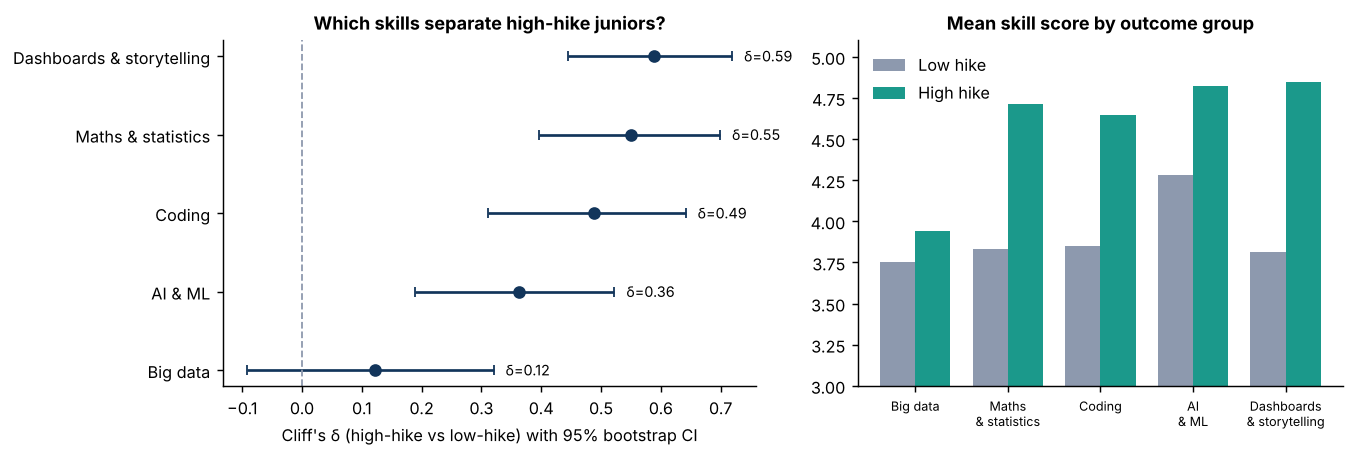

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6), gridspec_kw={"width_ratios":[1.1,1]})
e = eff.iloc[::-1]
ax[0].errorbar(e.delta, range(len(e)), xerr=[e.delta-e.ci_lo, e.ci_hi-e.delta], fmt="o", color=C["navy"], capsize=3)
ax[0].axvline(0, color=C["grey"], lw=1, ls="--"); ax[0].set_yticks(range(len(e))); ax[0].set_yticklabels(e.skill.map(NAMES))
ax[0].set_xlabel("Cliff's δ (high-hike vs low-hike) with 95% bootstrap CI"); ax[0].set_title("Which skills separate high-hike juniors?")
for i, r in enumerate(e.itertuples()): ax[0].text(r.ci_hi+0.02, i, f"δ={r.delta:.2f}", va="center", fontsize=8)
pos = np.arange(5); w = 0.38
lo_m = [eff.set_index("skill").loc[k, "mean_low"] for k in SK]; hi_m = [eff.set_index("skill").loc[k, "mean_high"] for k in SK]
ax[1].bar(pos-w/2, lo_m, w, color=C["grey"], label="Low hike"); ax[1].bar(pos+w/2, hi_m, w, color=C["teal"], label="High hike")
ax[1].set_xticks(pos); ax[1].set_xticklabels([NAMES[k].replace(" & ","\n& ") for k in SK], fontsize=7); ax[1].set_ylim(3, 5.1); ax[1].legend(frameon=False); ax[1].set_title("Mean skill score by outcome group")
plt.tight_layout(); plt.savefig("figs/fig02_jds_effects.png", bbox_inches="tight"); plt.show()

## 3. SDS (senior personality, 161 rows) — exploratory cohort context only

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score
SDS = pd.read_excel(f"{DATA_DIR}/SDS_Personality_Traits.xlsx"); SDS.columns = ["id","neuroticism","extraversion","openness","agreeableness","conscientiousness","success"]
TR = ["neuroticism","extraversion","openness","agreeableness","conscientiousness"]
print("rows", len(SDS), "| unique ids", SDS.id.nunique(), "| repeated-id rows", int(SDS.id.duplicated(keep=False).sum()))
rows = []
for k in TR:
    hi, lo = SDS.loc[SDS.success==1, k].values, SDS.loc[SDS.success==0, k].values
    d, p = cliffs_delta(hi, lo); rows.append(dict(trait=k, mean_low=lo.mean(), mean_high=hi.mean(), delta=d, p=p))
sds_eff = pd.DataFrame(rows); sds_eff["p_holm"] = multipletests(sds_eff.p, method="holm")[1]
print(sds_eff.round(4).to_string(index=False))
aucs = []
for r in range(20):
    cv = StratifiedGroupKFold(5, shuffle=True, random_state=r)
    oof = cross_val_predict(make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000)), SDS[TR].values, SDS.success.values, groups=SDS.id.values, cv=cv, method="predict_proba")[:,1]
    aucs.append(roc_auc_score(SDS.success, oof))
print(f"\nSDS logistic AUC (5-fold group-CV x20): {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")
save_res("sds", dict(effects=sds_eff.to_dict("records"), auc_mean=float(np.mean(aucs)), auc_sd=float(np.std(aucs)), n=len(SDS), unique_ids=int(SDS.id.nunique())))

rows 161 | unique ids 152 | repeated-id rows 18
            trait  mean_low  mean_high  delta      p  p_holm
      neuroticism   36.2632    36.1294 0.0686 0.4539  0.4539
     extraversion   36.8816    48.8588 0.5664 0.0000  0.0000
         openness   33.3158    48.4941 0.7698 0.0000  0.0000
    agreeableness   41.1184    47.7176 0.3042 0.0009  0.0017
conscientiousness   35.7368    53.6824 0.7551 0.0000  0.0000



SDS logistic AUC (5-fold group-CV x20): 0.962 ± 0.006
